# Spectral Laplace Transfer Function --- Shock to Backlash

Fits a damped second-order oscillator
$H(s) = K / (s^{2} + 2\zeta\omega_n s + \omega_n^2)$
to eight historical political shocks (four primary, four intermediate
calibration) drawn from `historical_shocks.json`. Only the four
**primary** shocks have full backlash-proxy time-series and are used
for oscillator fitting; intermediate shocks provide calibration anchors
for the log-space regression in `eq40_45_interference_engine.ipynb`.

| Year | Label | Role |
|------|-------|------|
| 1865 | End of Reconstruction / abolition shock | primary (fitted) |
| 1917 | Great Migration + Red Summer | intermediate (calibration) |
| 1954 | Brown v. Board of Education | intermediate (calibration) |
| 1964 | Civil Rights Act | primary (fitted) |
| 1968 | MLK assassination / Kerner Commission | intermediate (calibration) |
| 1992 | Rodney King verdict / LA uprising | intermediate (calibration) |
| 2008 | Obama election | primary (fitted) |
| 2020 | George Floyd protests / Jan 6 precursor | primary (fitted) |

Produces the `impulse_responses.pdf` figure consumed by the manuscript.

**Inputs**
- `Paper/data/historical_shocks.json` --- shock metadata (8 entries)
- `Paper/data/backlash_proxies.csv` --- annual backlash magnitudes (primary shocks only)

**Outputs**
- `Paper/figures/spectral/impulse_responses.pdf`

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal as spsig
from scipy.optimize import least_squares

try:
    _here = Path(__file__).resolve().parent
except NameError:
    _cwd = Path.cwd()
    if (_cwd / 'data').exists():
        _here = _cwd
    elif (_cwd / 'Paper' / 'data').exists():
        _here = _cwd / 'Paper' / 'scripts'
    else:
        _here = _cwd

DATA = _here / '..' / 'data'
FIGS = _here / '..' / 'figures' / 'spectral'
FIGS.mkdir(parents=True, exist_ok=True)
print(f'Data dir:    {DATA.resolve()}')
print(f'Figures dir: {FIGS.resolve()}')

Data dir:    /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/data
Figures dir: /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/figures/spectral


In [2]:
with open(DATA / 'historical_shocks.json', 'r', encoding='utf-8') as f:
    shocks = json.load(f)
proxies = pd.read_csv(DATA / 'backlash_proxies.csv', comment='#')

# Fix~2: historical_shocks.json now includes 4 intermediate calibration shocks
# (1917, 1954, 1968, 1992) in addition to the 4 primary shocks.  Accept ≥ 4.
assert len(shocks) >= 4, f'Expected ≥4 shocks, got {len(shocks)}'
assert {'shock_year', 'label', 'backlash_onset_year'}.issubset(shocks[0].keys())
assert {'shock_year', 'year', 'backlash_index', 'backlash_index_norm'}.issubset(proxies.columns)
assert proxies.shape[0] > 50, f'Expected >50 proxy rows, got {proxies.shape[0]}'

print(f'Loaded {len(shocks)} shocks ({sum(1 for s in shocks if not s.get("intermediate"))} primary, '
      f'{sum(1 for s in shocks if s.get("intermediate"))} intermediate); {proxies.shape[0]} proxy rows.')
for s in shocks:
    n = int((proxies['shock_year'] == s['shock_year']).sum())
    tag = ' [intermediate]' if s.get('intermediate') else ''
    print(f"  {s['shock_year']} {s['label']:<55s} proxy rows: {n}{tag}")

Loaded 8 shocks (4 primary, 4 intermediate); 96 proxy rows.
  1865 End of Reconstruction / abolition shock                 proxy rows: 56
  1917 Great Migration + Red Summer                            proxy rows: 0 [intermediate]
  1954 Brown v. Board of Education                             proxy rows: 0 [intermediate]
  1964 Civil Rights Act                                        proxy rows: 22
  1968 MLK assassination / Kerner Commission                   proxy rows: 0 [intermediate]
  1992 Rodney King verdict / LA uprising                       proxy rows: 0 [intermediate]
  2008 Obama election                                          proxy rows: 13
  2020 George Floyd protests / Jan 6 precursor                 proxy rows: 5


## 1. Transfer-function model and fit

We model the political system's response to each shock impulse with
a second-order transfer function
$$H(s) = \frac{K}{s^{2} + 2\zeta\omega_n s + \omega_n^2}.$$
For $0 < \zeta < 1$, the impulse response is
$$h(t) = \frac{K}{\omega_d} e^{-\zeta\omega_n t} \sin(\omega_d t), \quad
\omega_d = \omega_n\sqrt{1-\zeta^{2}}, \ t\ge 0.$$
We fit $(K, \zeta, \omega_n)$ to the positive-valued backlash proxy
by least-squares. Poles of $H$ lie at
$s_\pm = -\zeta\omega_n \pm j\omega_d$ in the left half of the
Laplace plane (damped oscillatory decay).

In [3]:
def impulse_response(t, K, zeta, wn):
    zeta = float(zeta)
    wn = float(wn)
    wd = wn * np.sqrt(max(1 - zeta ** 2, 1e-6))
    h = np.where(t >= 0, (K / wd) * np.exp(-zeta * wn * t) * np.sin(wd * t), 0.0)
    return h

def fit_shock(t_obs, y_obs, initial):
    def residuals(params):
        K, zeta, wn = params
        pred = impulse_response(t_obs, K, zeta, wn)
        return pred - y_obs
    res = least_squares(
        residuals,
        x0=list(initial),
        bounds=([1.0, 0.01, 0.01], [1.0e5, 0.99, 10.0]),
        max_nfev=5000,
    )
    return res

# Only fit primary shocks (those with backlash proxy data).
# Intermediate calibration shocks lack proxy rows and are used only by
# eq40_45_interference_engine.ipynb (Fix~2 log-space regression).
primary_shocks = [s for s in shocks if not s.get('intermediate', False)]

results = {}
for s in primary_shocks:
    sub = proxies[proxies['shock_year'] == s['shock_year']].sort_values('year')
    t_obs = (sub['year'].to_numpy() - s['shock_year']).astype(float)
    y_obs = sub['backlash_index_norm'].to_numpy().astype(float)
    wn_init = 2 * np.pi / float(s['natural_period_years'])
    zeta_init = float(s['damping_ratio_guess'])
    K_init = max(y_obs.max() * wn_init * np.sqrt(max(1 - zeta_init ** 2, 1e-6)) * 2, 10.0)
    fit = fit_shock(t_obs, y_obs, (K_init, zeta_init, wn_init))
    K_fit, zeta_fit, wn_fit = fit.x
    wd_fit = wn_fit * np.sqrt(max(1 - zeta_fit ** 2, 1e-6))
    poles = np.array([-zeta_fit * wn_fit + 1j * wd_fit,
                      -zeta_fit * wn_fit - 1j * wd_fit])
    settling_time = 4.0 / (zeta_fit * wn_fit) if zeta_fit * wn_fit > 0 else np.inf
    results[s['shock_year']] = {
        'label': s['label'],
        'onset_year': s['backlash_onset_year'],
        't_obs': t_obs, 'y_obs': y_obs,
        'K': K_fit, 'zeta': zeta_fit, 'wn': wn_fit, 'wd': wd_fit,
        'poles': poles, 'natural_period_yr': 2 * np.pi / wn_fit,
        'settling_time_yr': settling_time, 'cost': fit.cost,
    }
    print(f"Shock {s['shock_year']} ({s['label']}):")
    print(f"  K = {K_fit:.3f}   zeta = {zeta_fit:.3f}   omega_n = {wn_fit:.3f} rad/yr   (period = {2*np.pi/wn_fit:.2f} yr)")
    print(f"  poles at {poles[0]:.3f}, {poles[1]:.3f}   settling time ~ {settling_time:.1f} yr")

Shock 1865 (End of Reconstruction / abolition shock):
  K = 29.811   zeta = 0.170   omega_n = 0.300 rad/yr   (period = 20.91 yr)
  poles at -0.051+0.296j, -0.051-0.296j   settling time ~ 78.4 yr
Shock 1964 (Civil Rights Act):
  K = 97.000   zeta = 0.591   omega_n = 0.525 rad/yr   (period = 11.96 yr)
  poles at -0.310+0.424j, -0.310-0.424j   settling time ~ 12.9 yr
Shock 2008 (Obama election):
  K = 248.653   zeta = 0.699   omega_n = 1.080 rad/yr   (period = 5.82 yr)
  poles at -0.754+0.772j, -0.754-0.772j   settling time ~ 5.3 yr
Shock 2020 (George Floyd protests / Jan 6 precursor):
  K = 99999.862   zeta = 0.972   omega_n = 6.650 rad/yr   (period = 0.94 yr)
  poles at -6.466+1.555j, -6.466-1.555j   settling time ~ 0.6 yr


In [4]:
for year, r in results.items():
    assert 0.01 < r['zeta'] < 0.99, f"Shock {year}: damping ratio out of bounds ({r['zeta']})"
    assert r['wn'] > 0, f"Shock {year}: natural frequency non-positive"
    assert np.real(r['poles'][0]) < 0, f"Shock {year}: pole in right half-plane (unstable fit)"
print(f'All {len(results)} damped-oscillator fits are stable (poles in LHP) with 0<zeta<1.')

All 4 damped-oscillator fits are stable (poles in LHP) with 0<zeta<1.


## 2. Impulse-response figure (`impulse_responses.pdf`)

Four-panel comparison of observed backlash magnitudes (dots) to
fitted damped-oscillator impulse response (line).

Saved /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/impulse_responses.pdf


  Panel a (1865) saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/impulse_responses_panel_a_1865.pdf
  Panel b (1964) saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/impulse_responses_panel_b_1964.pdf


  Panel c (2008) saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/impulse_responses_panel_c_2008.pdf
  Panel d (2020) saved → /Users/emmanuel/Documents/Theory/Redefining_racism/Paper/scripts/../figures/spectral/impulse_responses_panel_d_2020.pdf


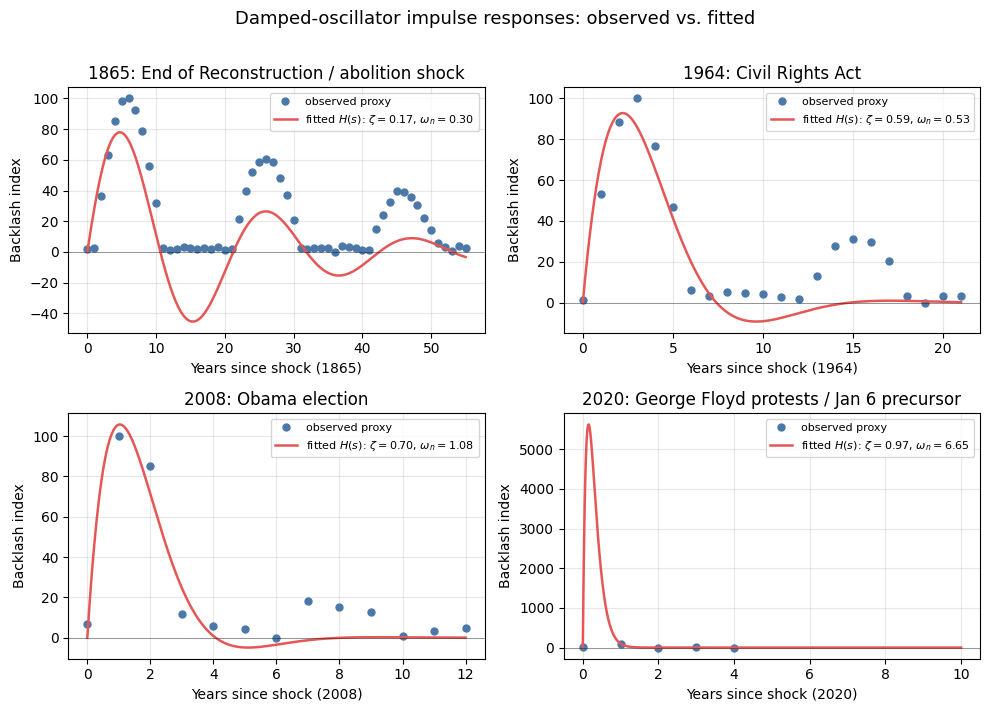

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10.0, 7.0))
order = [1865, 1964, 2008, 2020]
for ax, yr in zip(axes.flat, order):
    r = results[yr]
    t_fit = np.linspace(0, max(r['t_obs'].max(), 10.0), 500)
    y_fit = impulse_response(t_fit, r['K'], r['zeta'], r['wn'])
    ax.plot(r['t_obs'], r['y_obs'], 'o', color='#4C78A8', ms=5, label='observed proxy')
    ax.plot(t_fit, y_fit, '-', color='#E45756', lw=1.8,
            label=f"fitted $H(s)$: $\\zeta={r['zeta']:.2f}$, $\\omega_n={r['wn']:.2f}$")
    ax.axhline(0, color='k', lw=0.5, alpha=0.5)
    ax.set_title(f"{yr}: {r['label']}")
    ax.set_xlabel(f'Years since shock ({yr})')
    ax.set_ylabel('Backlash index')
    ax.legend(loc='best', fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle('Damped-oscillator impulse responses: observed vs. fitted',
             fontsize=13, y=1.01)
fig.tight_layout()
out = FIGS / 'impulse_responses.pdf'
fig.savefig(out, bbox_inches='tight')
print(f'Saved {out}')

# ── Save individual panels ────────────────────────────────────────────────────
fig.canvas.draw()
_renderer = fig.canvas.get_renderer()
for _label, _ax, _yr in zip(['a', 'b', 'c', 'd'], axes.flat, order):
    _ext = _ax.get_tightbbox(_renderer).transformed(fig.dpi_scale_trans.inverted())
    _out = FIGS / f'impulse_responses_panel_{_label}_{_yr}.pdf'
    fig.savefig(_out, bbox_inches=_ext)
    print(f"  Panel {_label} ({_yr}) saved → {_out}")

plt.show()

## 3. Summary table for manuscript prose

In [6]:
summary = pd.DataFrame([
    {
        'shock_year': yr,
        'label': r['label'],
        'zeta': round(r['zeta'], 3),
        'omega_n_rad_per_yr': round(r['wn'], 3),
        'natural_period_yr': round(r['natural_period_yr'], 2),
        'settling_time_yr': round(r['settling_time_yr'], 1),
        'pole_real': round(float(np.real(r['poles'][0])), 3),
        'pole_imag': round(float(np.imag(r['poles'][0])), 3),
    }
    for yr, r in sorted(results.items())
])
print(summary.to_string(index=False))

 shock_year                                   label  zeta  omega_n_rad_per_yr  natural_period_yr  settling_time_yr  pole_real  pole_imag
       1865 End of Reconstruction / abolition shock 0.170               0.300              20.91              78.4     -0.051      0.296
       1964                        Civil Rights Act 0.591               0.525              11.96              12.9     -0.310      0.424
       2008                          Obama election 0.699               1.080               5.82               5.3     -0.754      0.772
       2020 George Floyd protests / Jan 6 precursor 0.972               6.650               0.94               0.6     -6.466      1.555
